In [1]:
import pandas as pd
from scipy.stats import norm
import numpy as np
import pyreadr
import itertools
import pingouin as pg
import itertools
import glob
import seaborn as sns
import os
import re
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt


In [2]:
df_controle = pd.read_csv(r"..\dados\raios_espectrais\raios_espectrais_controle.csv")
df_autismo = pd.read_csv(r"..\dados\raios_espectrais\raios_espectrais_autismo.csv")

In [3]:
df_controle.describe()

,Somatomotor,Visual,Default_mode,Cerebellar,Control
count,529.000000,529.000000,529.000000,529.000000,529.000000
mean,38.258393,31.335992,43.864592,22.120293,22.015975
std,9.307974,7.082177,9.974780,6.704955,4.882626
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.177793,27.325734,38.322524,18.037901,19.364459
50%,39.287472,31.771544,45.137745,22.020204,22.162835
75%,44.567384,36.229756,50.155480,25.982764,25.421786
max,58.001062,48.216685,67.681679,41.040960,32.773025


In [4]:
df_autismo.describe()

,Somatomotor,Visual,Default_mode,Cerebellar,Control
count,285.000000,285.000000,285.000000,285.000000,285.000000
mean,35.477500,30.736035,40.741100,20.075884,20.352975
std,9.748948,7.522864,11.063462,7.045963,5.436625
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.494729,27.097328,35.091811,16.163032,17.962742
50%,36.379018,30.303992,41.294576,19.596330,20.965722
75%,41.804510,35.072437,47.993195,24.743365,23.617706
max,57.536206,50.116835,66.166955,37.933919,32.022130


### Outliers

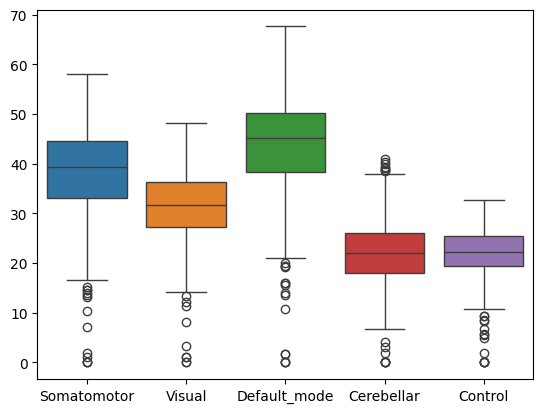

In [5]:
sns.boxplot(df_controle);

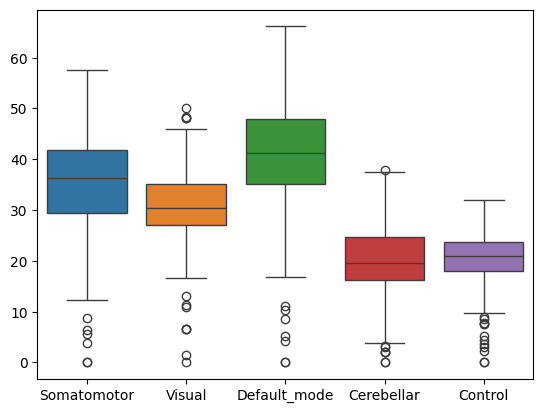

In [6]:
sns.boxplot(df_autismo);

### Analisando correlações

#### 1) Correlações de Spearman

In [7]:

correlacoes_spearman_controle = pg.pairwise_corr(df_controle, method="spearman", padjust="fdr_bh", alternative="two-sided")
correlacoes_spearman_autismo = pg.pairwise_corr(df_autismo, method="spearman", padjust="fdr_bh", alternative="two-sided")

print("CORRELAÇÕES DE SPEARMAN PARA CONJUNTO CONTROLE")
display(correlacoes_spearman_controle)


print("\nCORRELAÇÕES DE SPEARMAN PARA CONJUNTO AUTISMO")
display(correlacoes_spearman_autismo)

CORRELAÇÕES DE SPEARMAN PARA CONJUNTO CONTROLE


,X,Y,method,alternative,n,r,CI95%,p-unc,p-corr,p-adjust,power
0,Somatomotor,Visual,spearman,two-sided,529,0.371455,"[0.3, 0.44]",9.438246e-19,1.573041e-18,fdr_bh,1.000000
1,Somatomotor,Default_mode,spearman,two-sided,529,0.398306,"[0.32, 0.47]",1.472473e-21,4.908242e-21,fdr_bh,1.000000
2,Somatomotor,Cerebellar,spearman,two-sided,529,0.378712,"[0.3, 0.45]",1.744517e-19,3.489035e-19,fdr_bh,1.000000
3,Somatomotor,Control,spearman,two-sided,529,0.442705,"[0.37, 0.51]",8.475798e-27,4.237899e-26,fdr_bh,1.000000
4,Visual,Default_mode,spearman,two-sided,529,0.360902,"[0.28, 0.43]",1.019781e-17,1.274727e-17,fdr_bh,1.000000
5,Visual,Cerebellar,spearman,two-sided,529,0.384281,"[0.31, 0.45]",4.639086e-20,1.159772e-19,fdr_bh,1.000000
6,Visual,Control,spearman,two-sided,529,0.361126,"[0.28, 0.43]",9.703943e-18,1.274727e-17,fdr_bh,1.000000
7,Default_mode,Cerebellar,spearman,two-sided,529,0.195193,"[0.11, 0.28]",6.114393e-06,6.114393e-06,fdr_bh,0.995044
8,Default_mode,Control,spearman,two-sided,529,0.485470,"[0.42, 0.55]",1.244059e-32,1.244059e-31,fdr_bh,1.000000
9,Cerebellar,Control,spearman,two-sided,529,0.341451,"[0.26, 0.41]",6.536920e-16,7.263244e-16,fdr_bh,1.000000



CORRELAÇÕES DE SPEARMAN PARA CONJUNTO AUTISMO


,X,Y,method,alternative,n,r,CI95%,p-unc,p-corr,p-adjust,power
0,Somatomotor,Visual,spearman,two-sided,285,0.465596,"[0.37, 0.55]",9.702428e-17,1.386061e-16,fdr_bh,1.000000
1,Somatomotor,Default_mode,spearman,two-sided,285,0.579729,"[0.5, 0.65]",5.474315e-27,1.824772e-26,fdr_bh,1.000000
2,Somatomotor,Cerebellar,spearman,two-sided,285,0.506077,"[0.41, 0.59]",6.099133e-20,1.219827e-19,fdr_bh,1.000000
3,Somatomotor,Control,spearman,two-sided,285,0.593084,"[0.51, 0.66]",1.826097e-28,9.130483e-28,fdr_bh,1.000000
4,Visual,Default_mode,spearman,two-sided,285,0.516617,"[0.43, 0.6]",7.578163e-21,1.894541e-20,fdr_bh,1.000000
5,Visual,Cerebellar,spearman,two-sided,285,0.404262,"[0.3, 0.5]",1.246688e-12,1.385209e-12,fdr_bh,1.000000
6,Visual,Control,spearman,two-sided,285,0.499191,"[0.41, 0.58]",2.292549e-19,3.820914e-19,fdr_bh,1.000000
7,Default_mode,Cerebellar,spearman,two-sided,285,0.283205,"[0.17, 0.39]",1.174437e-06,1.174437e-06,fdr_bh,0.998345
8,Default_mode,Control,spearman,two-sided,285,0.649705,"[0.58, 0.71]",1.449842e-35,1.449842e-34,fdr_bh,1.000000
9,Cerebellar,Control,spearman,two-sided,285,0.440905,"[0.34, 0.53]",5.512633e-15,6.890792e-15,fdr_bh,1.000000


#### 2) Correlações Parciais de Spearman dois-dois

In [8]:
def calcular_correlacoes_parciais(df, method='spearman', ajuste="fdr_bh", alpha=0.05):
    colunas = df.columns
    combinacoes = list(itertools.combinations(colunas, 2))
    correlacoes_parciais = pd.DataFrame()
    for col1, col2 in combinacoes:
        covariaveis = [i for i in colunas if i not in (col1, col2)]
        df_i = pg.pairwise_corr(df, method=method, alternative="two-sided", covar=covariaveis)
        correlacoes_parciais = pd.concat([correlacoes_parciais, df_i], ignore_index=True)

    reject_h0, p_corr = pg.multicomp(correlacoes_parciais['p-unc'].values, method=ajuste, alpha=alpha)

    # 3. Adicionamos os resultados ao DataFrame final
    correlacoes_parciais['p-corr'] = p_corr
    correlacoes_parciais['reject_h0'] = reject_h0

    return correlacoes_parciais

In [9]:
print("CORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO CONTROLE")
correlacoes_parciais_controle = calcular_correlacoes_parciais(df_controle, method="spearman", ajuste="bonf", alpha=0.05)
display(correlacoes_parciais_controle)


print("\nCORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO AUTISMO")
correlacoes_parciais_autismo = calcular_correlacoes_parciais(df_autismo, method="spearman", ajuste="bonf", alpha=0.05)
display(correlacoes_parciais_autismo)


CORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO CONTROLE


,X,Y,method,covar,alternative,n,r,CI95%,p-unc,p-corr,reject_h0
0,Somatomotor,Visual,spearman,"['Default_mode', 'Cerebellar', 'Control']",two-sided,529,0.142369,"[0.06, 0.23]",1.059972e-03,1.059972e-02,True
1,Somatomotor,Default_mode,spearman,"['Visual', 'Cerebellar', 'Control']",two-sided,529,0.199013,"[0.12, 0.28]",4.234412e-06,4.234412e-05,True
2,Somatomotor,Cerebellar,spearman,"['Visual', 'Default_mode', 'Control']",two-sided,529,0.221240,"[0.14, 0.3]",2.965221e-07,2.965221e-06,True
3,Somatomotor,Control,spearman,"['Visual', 'Default_mode', 'Cerebellar']",two-sided,529,0.218737,"[0.14, 0.3]",4.058281e-07,4.058281e-06,True
4,Visual,Default_mode,spearman,"['Somatomotor', 'Cerebellar', 'Control']",two-sided,529,0.192280,"[0.11, 0.27]",8.958641e-06,8.958641e-05,True
5,Visual,Cerebellar,spearman,"['Somatomotor', 'Default_mode', 'Control']",two-sided,529,0.255773,"[0.17, 0.33]",2.658562e-09,2.658562e-08,True
6,Visual,Control,spearman,"['Somatomotor', 'Default_mode', 'Cerebellar']",two-sided,529,0.107696,"[0.02, 0.19]",1.346263e-02,1.346263e-01,False
7,Default_mode,Cerebellar,spearman,"['Somatomotor', 'Visual', 'Control']",two-sided,529,-0.076896,"[-0.16, 0.01]",7.806964e-02,7.806964e-01,False
8,Default_mode,Control,spearman,"['Somatomotor', 'Visual', 'Cerebellar']",two-sided,529,0.343897,"[0.27, 0.42]",4.767173e-16,4.767173e-15,True
9,Cerebellar,Control,spearman,"['Somatomotor', 'Visual', 'Default_mode']",two-sided,529,0.169561,"[0.09, 0.25]",9.309402e-05,9.309402e-04,True



CORRELAÇÕES PARCIAIS DE SPEARMAN DOIS-DOIS CONJUNTO AUTISMO


,X,Y,method,covar,alternative,n,r,CI95%,p-unc,p-corr,reject_h0
0,Somatomotor,Visual,spearman,"['Default_mode', 'Cerebellar', 'Control']",two-sided,285,0.084528,"[-0.03, 0.2]",1.568643e-01,1.000000e+00,False
1,Somatomotor,Default_mode,spearman,"['Visual', 'Cerebellar', 'Control']",two-sided,285,0.304337,"[0.19, 0.41]",1.866681e-07,1.866681e-06,True
2,Somatomotor,Cerebellar,spearman,"['Visual', 'Default_mode', 'Control']",two-sided,285,0.332178,"[0.22, 0.43]",1.086853e-08,1.086853e-07,True
3,Somatomotor,Control,spearman,"['Visual', 'Default_mode', 'Cerebellar']",two-sided,285,0.217600,"[0.1, 0.33]",2.313114e-04,2.313114e-03,True
4,Visual,Default_mode,spearman,"['Somatomotor', 'Cerebellar', 'Control']",two-sided,285,0.260576,"[0.15, 0.37]",9.284352e-06,9.284352e-05,True
5,Visual,Cerebellar,spearman,"['Somatomotor', 'Default_mode', 'Control']",two-sided,285,0.205984,"[0.09, 0.32]",4.993612e-04,4.993612e-03,True
6,Visual,Control,spearman,"['Somatomotor', 'Default_mode', 'Cerebellar']",two-sided,285,0.135475,"[0.02, 0.25]",2.288185e-02,2.288185e-01,False
7,Default_mode,Cerebellar,spearman,"['Somatomotor', 'Visual', 'Control']",two-sided,285,-0.172544,"[-0.28, -0.06]",3.655456e-03,3.655456e-02,True
8,Default_mode,Control,spearman,"['Somatomotor', 'Visual', 'Cerebellar']",two-sided,285,0.423063,"[0.32, 0.51]",1.132769e-13,1.132769e-12,True
9,Cerebellar,Control,spearman,"['Somatomotor', 'Visual', 'Default_mode']",two-sided,285,0.201669,"[0.09, 0.31]",6.577262e-04,6.577262e-03,True


#### 3) Comparação de correlações com Fisher Z test

In [10]:
def fisher_z_test(r1, r2, n1, n2):
    """
    Testa a diferença entre duas correlações independentes.
    
    Parâmetros:
    r1, r2: Coeficientes de correlação (ex: Controle e TEA)
    n1, n2: Tamanho das amostras dos respectivos grupos
    
    Retorna:
    Z-statistic, p-value
    """
    # Passo 1: Transformação r-to-z (arctanh é a mesma coisa que a fórmula do log)
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    
    # Passo 2: Calcular o Erro Padrão e a Estatística Z
    se = np.sqrt((1 / (n1 - 3)) + (1 / (n2 - 3)))
    z_stat = (z1 - z2) / se
    
    # Passo 3: Calcular o p-valor (teste bicaudal)
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))
    
    return p_value



def fisher_z_test_spearman(r1, r2, n1, n2):
    """
    Testa a diferença entre duas correlações independentes de Spearman, com correção para inflação
    de variância de rank (i.e., penalização do SE em 1.06).
    
    Parâmetros:
    r1, r2: Coeficientes de correlação de Spearman (ex: Controle e TEA)
    n1, n2: Tamanho das amostras dos respectivos grupos
    
    Retorna:
    p-value
    """
    # Passo 1: Transformação r-to-z (arctanh é a mesma coisa que a fórmula do log)
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    
    # Passo 2: Calcular o Erro Padrão com a penalidade matemática para Spearman (1.06)
    se = np.sqrt((1.06 / (n1 - 3)) + (1.06 / (n2 - 3)))
    
    # Calcular a estatística Z
    z_stat = (z1 - z2) / se
    
    # Passo 3: Calcular o p-valor (teste bicaudal)
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))

    return p_value

In [11]:
correlacoes = correlacoes_spearman_controle[["X", "Y", "r"]].copy().rename(columns={"r":"correlacoes_controle"})
correlacoes["correlacoes_autismo"] = correlacoes_spearman_autismo["r"]

In [12]:
correlacoes_parciais = correlacoes_parciais_controle[["X", "Y", "covar", "r"]]\
    .copy()\
    .rename(columns={"r":"correlacoes_controle"})

correlacoes_parciais["correlacoes_autismo"] = correlacoes_parciais_autismo["r"]

##### 3.1) Utilizando SE sem penalidade

In [13]:
print("CORRELAÇÕES DE SPEARMAN")
correlacoes["p-value"] = correlacoes.apply(lambda x: fisher_z_test(r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                                        axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes["p-value-adj"] = p_corr
correlacoes

CORRELAÇÕES DE SPEARMAN


,X,Y,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,0.371455,0.465596,0.121388,0.151735
1,Somatomotor,Default_mode,0.398306,0.579729,0.001124,0.005620
2,Somatomotor,Cerebellar,0.378712,0.506077,0.031336,0.052227
3,Somatomotor,Control,0.442705,0.593084,0.005075,0.016917
4,Visual,Default_mode,0.360902,0.516617,0.008647,0.021617
5,Visual,Cerebellar,0.384281,0.404262,0.748533,0.748533
6,Visual,Control,0.361126,0.499191,0.021223,0.042446
7,Default_mode,Cerebellar,0.195193,0.283205,0.205536,0.228373
8,Default_mode,Control,0.485470,0.649705,0.000916,0.005620
9,Cerebellar,Control,0.341451,0.440905,0.111019,0.151735


- Visual ~ Default_mode
- Visual ~ Control
- Somatomotor ~ Default_mode
- Somatormotor ~  Control
- Control ~ Default_mode

In [14]:
print("CORRELAÇÃO PARCIAL")
correlacoes_parciais["p-value"] = correlacoes_parciais.apply(lambda x: fisher_z_test(r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                                        axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes_parciais['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes_parciais["p-value-adj"] = p_corr
correlacoes_parciais

CORRELAÇÃO PARCIAL


,X,Y,covar,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,"['Default_mode', 'Cerebellar', 'Control']",0.142369,0.084528,0.427111,0.679976
1,Somatomotor,Default_mode,"['Visual', 'Cerebellar', 'Control']",0.199013,0.304337,0.127143,0.520196
2,Somatomotor,Cerebellar,"['Visual', 'Default_mode', 'Control']",0.221240,0.332178,0.103066,0.520196
3,Somatomotor,Control,"['Visual', 'Default_mode', 'Cerebellar']",0.218737,0.217600,0.987095,0.987095
4,Visual,Default_mode,"['Somatomotor', 'Cerebellar', 'Control']",0.192280,0.260576,0.329140,0.658281
5,Visual,Cerebellar,"['Somatomotor', 'Default_mode', 'Control']",0.255773,0.205984,0.475983,0.679976
6,Visual,Control,"['Somatomotor', 'Default_mode', 'Cerebellar']",0.107696,0.135475,0.702424,0.780471
7,Default_mode,Cerebellar,"['Somatomotor', 'Visual', 'Control']",-0.076896,-0.172544,0.187669,0.520196
8,Default_mode,Control,"['Somatomotor', 'Visual', 'Cerebellar']",0.343897,0.423063,0.208079,0.520196
9,Cerebellar,Control,"['Somatomotor', 'Visual', 'Default_mode']",0.169561,0.201669,0.652281,0.780471


##### 3.2) Utilizando SE com penalidade

In [15]:
correlacoes["p-value"] = correlacoes.apply(lambda x: fisher_z_test_spearman(
                                                        r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                            axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes["p-value-adj"] = p_corr
correlacoes

,X,Y,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,0.371455,0.465596,0.132454,0.165567
1,Somatomotor,Default_mode,0.398306,0.579729,0.001556,0.007782
2,Somatomotor,Cerebellar,0.378712,0.506077,0.036532,0.060886
3,Somatomotor,Control,0.442705,0.593084,0.006493,0.021645
4,Visual,Default_mode,0.360902,0.516617,0.010763,0.026907
5,Visual,Cerebellar,0.384281,0.404262,0.755520,0.755520
6,Visual,Control,0.361126,0.499191,0.025232,0.050464
7,Default_mode,Cerebellar,0.195193,0.283205,0.218852,0.243169
8,Default_mode,Control,0.485470,0.649705,0.001282,0.007782
9,Cerebellar,Control,0.341451,0.440905,0.121654,0.165567


- Visual ~ Default_mode
- Somatomotor ~ Control
- Somatomotor ~ Default_mode
- Control ~ Default_mode

In [16]:
print("CORRELAÇÃO PARCIAL")
correlacoes_parciais["p-value"] = correlacoes_parciais.apply(lambda x: fisher_z_test_spearman(r1=x["correlacoes_controle"], 
                                                        r2=x["correlacoes_autismo"], 
                                                        n1=529, 
                                                        n2=285), 
                                                        axis=1)

reject_h0, p_corr = pg.multicomp(correlacoes_parciais['p-value'].values, method="fdr_bh", alpha=0.05)
correlacoes_parciais["p-value-adj"] = p_corr
correlacoes_parciais

CORRELAÇÃO PARCIAL


,X,Y,covar,correlacoes_controle,correlacoes_autismo,p-value,p-value-adj
0,Somatomotor,Visual,"['Default_mode', 'Cerebellar', 'Control']",0.142369,0.084528,0.440504,0.698203
1,Somatomotor,Default_mode,"['Visual', 'Cerebellar', 'Control']",0.199013,0.304337,0.138430,0.553589
2,Somatomotor,Cerebellar,"['Visual', 'Default_mode', 'Control']",0.221240,0.332178,0.113339,0.553589
3,Somatomotor,Control,"['Visual', 'Default_mode', 'Cerebellar']",0.218737,0.217600,0.987466,0.987466
4,Visual,Default_mode,"['Somatomotor', 'Cerebellar', 'Control']",0.192280,0.260576,0.343218,0.686436
5,Visual,Cerebellar,"['Somatomotor', 'Default_mode', 'Control']",0.255773,0.205984,0.488742,0.698203
6,Visual,Control,"['Somatomotor', 'Default_mode', 'Cerebellar']",0.107696,0.135475,0.710578,0.789531
7,Default_mode,Cerebellar,"['Somatomotor', 'Visual', 'Control']",-0.076896,-0.172544,0.200660,0.553589
8,Default_mode,Control,"['Somatomotor', 'Visual', 'Cerebellar']",0.343897,0.423063,0.221436,0.553589
9,Cerebellar,Control,"['Somatomotor', 'Visual', 'Default_mode']",0.169561,0.201669,0.661635,0.789531


### Figura SEM

#### Caso 1

In [68]:
import graphviz
import os

# 1. Cria o objeto do grafo direcionado e define o formato de saída como PDF
diagrama = graphviz.Digraph(name='Diagrama_SEM_TopDown', format='pdf')

# 2. Define a direção do layout como de cima para baixo (Top-to-Bottom)
diagrama.attr(rankdir='TB')

# 3. Define estilos padrões para nós (variáveis observáveis) e arestas
diagrama.attr('node', shape='box', style='filled', fillcolor='lightgrey', fontname='Arial', fontsize='14', margin='0.25,0.15')
diagrama.attr('edge', fontname='Arial', fontsize='10', arrowsize='1')

# 4. Criando os nós
# DICA: Use IDs internos simples (ex: 'l1', 'l2') para evitar erros com as portas (:n).
# Para usar HTML-like labels no Graphviz e ter sub/sobrescrito perfeito, o texto deve ficar dentro de < >.
# <sup> = sobrescrito | <sub> = subscrito | &lambda; ou o próprio λ = símbolo grego
diagrama.node('l1', label='<<sup>1</sup>λ<sub>1</sub>>')
diagrama.node('l2', label='<<sup>2</sup>λ<sub>1</sub>>')

# 5. Criando as Variâncias
# Agora referenciamos os IDs simples criados acima ('l1' e 'l2')
diagrama.edge('l1:n', 'l1:n', label='', dir='both')
diagrama.edge('l2:n', 'l2:n', label='', dir='both')

# 6. Renderiza e salva o PDF
folder_path = r"..\resultados\figuras\modelos_sem"

# Cria a pasta caso não exista
os.makedirs(folder_path, exist_ok=True) 

path_final = os.path.join(folder_path, 'SEM_simu_1')
diagrama.render(path_final, view=False, cleanup=True)

print(f"Diagrama gerado com sucesso em: {path_final}.pdf")

Diagrama gerado com sucesso em: ..\resultados\figuras\modelos_sem\SEM_simu_1.pdf


#### Caso 2

In [67]:
import graphviz
import os

diagrama = graphviz.Digraph(name='SEM_simulacao_Vertical', format='pdf')

# 1. ESPAÇAMENTO GERAL
diagrama.attr(rankdir='TB', nodesep='0.8', ranksep='0.8', pad='0.5') 

# 2. TAMANHO DOS QUADRADOS (NÓS)
diagrama.attr('node', shape='box', style='filled', fillcolor='lightgrey', fontname='Arial', fontsize='14', margin='0.25,0.15')

# 3. TAMANHO DAS SETAS
diagrama.attr('edge', fontname='Arial', fontsize='10', arrowsize='1')

# =====================================================================
# MODELO SUPERIOR (Antigo Cenário A)
# =====================================================================
with diagrama.subgraph(name='cluster_m1') as m1:
    m1.attr(color='white') # Mantemos a borda branca para ocultar o contorno do cluster
    
    m1.node('m1_l1', label='<<sup>1</sup>λ<sub>1</sub>>')
    m1.node('m1_l2', label='<<sup>2</sup>λ<sub>1</sub>>')
    
    m1.edge('m1_l1', 'm1_l2')
    
    m1.edge('m1_l1:n', 'm1_l1:n', dir='both', label='   ')
    m1.edge('m1_l2:n', 'm1_l2:n', dir='both', label='   ')
    
    m1.body.append('{rank=same; m1_l1; m1_l2}')

# =====================================================================
# MODELO INFERIOR (Antigo Cenário B)
# =====================================================================
with diagrama.subgraph(name='cluster_m2') as m2:
    m2.attr(color='white') 
    
    m2.node('m2_l1', label='<<sup>1</sup>λ<sub>1</sub>>')
    m2.node('m2_l2', label='<<sup>2</sup>λ<sub>1</sub>>')
    
    m2.edge('m2_l1', 'm2_l2', dir='back')
    
    m2.edge('m2_l1:n', 'm2_l1:n', dir='both', label='   ')
    m2.edge('m2_l2:n', 'm2_l2:n', dir='both', label='   ')
    
    m2.body.append('{rank=same; m2_l1; m2_l2}')

# =====================================================================
# ALINHAMENTO VERTICAL (Invisível)
# =====================================================================
diagrama.edge('m1_l1', 'm2_l1', style='invis', weight='100')
diagrama.edge('m1_l2', 'm2_l2', style='invis', weight='100')

# =====================================================================
# SALVANDO O ARQUIVO FINAL
# =====================================================================
folder_path = r"..\resultados\figuras\modelos_sem"
os.makedirs(folder_path, exist_ok=True) 

path_final = os.path.join(folder_path, "SEM_simu_2")
diagrama.render(path_final, view=False, cleanup=True)

print(f"Diagrama sem labels gerado com sucesso! Salvo em: {path_final}.pdf")

Diagrama sem labels gerado com sucesso! Salvo em: ..\resultados\figuras\modelos_sem\SEM_simu_2.pdf


#### Caso 3

In [78]:
import graphviz
import os

# 1. Cria o objeto do grafo
diagrama = graphviz.Digraph(name='Diagrama_SEM_Triangulo', format='pdf')

# 2. Configurações Globais
# ranksep aumenta a altura do triângulo, nodesep aumenta a largura da base
diagrama.attr(rankdir='TB', splines='true', nodesep='1.2', ranksep='1.0')

# 3. Estilo dos nós e arestas
diagrama.attr('node', shape='box', style='filled', fillcolor='lightgrey', fontname='Arial', fontsize='12', margin='0.25,0.15')
diagrama.attr('edge', fontname='Arial', fontsize='10', arrowsize='0.6')

# 4. Criando os nós
diagrama.node('l1', label='<<sup>1</sup>λ<sub>1</sub>>')
diagrama.node('l2', label='<<sup>2</sup>λ<sub>1</sub>>')
diagrama.node('l3', label='<<sup>3</sup>λ<sub>1</sub>>')

# 5. Criando as relações (Arestas Causais)
# Graphviz calculará as diagonais automaticamente
diagrama.edge('l1', 'l2')
diagrama.edge('l1', 'l3')
diagrama.edge('l2', 'l3')

# O TRUQUE DO TRIÂNGULO:
# Forçamos l2 e l3 a ficarem exatamente na mesma linha horizontal (a base do triângulo)
diagrama.body.append('{rank=same; l2; l3}')

# 6. Criando as Variâncias sem sobreposição
# Para o l1 (topo do triângulo), a variância continua no topo (Noroeste para Nordeste)
diagrama.edge('l1:n', 'l1:n', label='   ', dir='both')

# Para l2 e l3 (base do triângulo), as setas causais estão chegando pelo topo.
# Então, colocamos as variâncias na parte de BAIXO das caixas (Sudoeste para Sudeste)
diagrama.edge('l2:s', 'l2:s', label='   ', dir='both')
diagrama.edge('l3:s', 'l3:s', label='   ', dir='both')

# 7. Renderiza e salva o PDF
folder_path = r"..\resultados\figuras\modelos_sem"

# Cria a pasta caso não exista
os.makedirs(folder_path, exist_ok=True) 

path_final = os.path.join(folder_path, 'SEM_simu_3')
diagrama.render(path_final, view=False, cleanup=True)

print(f"Diagrama em formato de triângulo gerado com sucesso em: {path_final}.pdf")

Diagrama em formato de triângulo gerado com sucesso em: ..\resultados\figuras\modelos_sem\SEM_simu_3.pdf


### Atlas and ROIs, label verification 

In [23]:
def mapeamento_roi_cluster(cluster):
    df_labels = pd.read_csv(r"..\dados\CC400_ROI_labels.csv", 
                        sep=",", 
                        header=0
                        )
    labels_scrubbing = pyreadr.read_r(r"..\dados\labelsComScrubbing_Nclusters_collection\labelsComScrubbing_5clusters.RData")["labels"]

    rois_cluster_i = labels_scrubbing[labels_scrubbing["labels"] == cluster].index.values + 1
    nome_rois_cluster_i = df_labels[df_labels["ROI number"].isin(rois_cluster_i)]
    return nome_rois_cluster_i

In [24]:
rois_cluster_1 = mapeamento_roi_cluster(cluster=1)
rois_cluster_2 = mapeamento_roi_cluster(cluster=2)

In [25]:
rois_cluster_1

,ROI number,volume,center of mass,Dosenbach,AAL,Eickhoff-Zilles,Talairach-Tournoux,Harvard-Oxford
0,1,111,(-10.5;-49.4;-7.3),"[""None"": 0.94]","[""Cerebelum_4_5_L"": 0.64][""Lingual_L"": 0.29]","[""Left Cerebellum"": 0.67][""Left Lingual Gyrus""...","[""Left Culmen"": 0.82]","[""Left Lingual Gyrus"": 0.58][""None"": 0.30]"
16,17,73,(40.6;-62.7;-34.9),"[""None"": 0.96]","[""Cerebelum_Crus1_R"": 0.89][""Cerebelum_Crus2_R...","[""Right Cerebellum"": 0.47][""Right Cerebellum"":...","[""Right Cerebellar Tonsil"": 0.49][""Right Infer...","[""None"": 1.00]"
17,18,96,(-19.8;-69.3;-25.9),"[""None"": 0.90]","[""Cerebelum_6_L"": 0.60][""Cerebelum_Crus1_L"": 0...","[""Left Cerebellum"": 0.59][""Left Cerebellum"": 0...","[""Left Uvula"": 0.36][""Left Pyramis"": 0.30][""Le...","[""None"": 1.00]"
20,21,94,(-6.8;-11.6;10.9),"[""None"": 0.85][""thalamus"": 0.12]","[""Thalamus_L"": 0.91]","[""Left Thalamus"": 0.91]","[""Left Thalamus"": 0.95]","[""Left Thalamus"": 1.00]"
23,24,155,(-15.2;-91.6;-14.1),"[""None"": 1.00]","[""Lingual_L"": 0.43][""Cerebelum_Crus1_L"": 0.28]...","[""Left Lingual Gyrus"": 0.54][""Left Cerebellum""...","[""Left Lingual Gyrus"": 0.46][""Left Fusiform Gy...","[""Left Occipital Pole"": 0.40][""Left Occipital ..."
...,...,...,...,...,...,...,...,...
293,297,112,(-5.7;57.9;23.0),"[""None"": 0.99]","[""Frontal_Sup_Medial_L"": 0.89][""Frontal_Sup_L""...","[""Left Superior Medial Gyrus"": 0.88][""Left Sup...","[""Left Superior Frontal Gyrus"": 0.66][""Left Me...","[""Left Frontal Pole"": 0.57][""Left Superior Fro..."
300,304,106,(29.1;-4.5;53.2),"[""None"": 1.00]","[""Precentral_R"": 0.44][""Frontal_Mid_R"": 0.29][...","[""RightPrecentral Gyrus"": 0.53][""Right Superio...","[""Right Middle Frontal Gyrus"": 0.84][""Right Pr...","[""Right Precentral Gyrus"": 0.54][""Right Middle..."
301,305,142,(-57.5;-10.3;10.6),"[""None"": 0.97]","[""Temporal_Sup_L"": 0.39][""Rolandic_Oper_L"": 0....","[""Left Superior Temporal Gyrus"": 0.44][""Left R...","[""Left Superior Temporal Gyrus"": 0.41][""Left P...","[""Left Central Opercular Cortex"": 0.50][""Left ..."
306,310,96,(17.4;-41.1;-27.5),"[""None"": 1.00]","[""None"": 0.40][""Cerebelum_4_5_R"": 0.38][""Cereb...","[""None"": 0.42][""Right Cerebellum"": 0.24][""Righ...","[""Right Cerebellar Tonsil"": 0.43][""Right Culme...","[""None"": 0.96]"


In [26]:
rois_cluster_2

,ROI number,volume,center of mass,Dosenbach,AAL,Eickhoff-Zilles,Talairach-Tournoux,Harvard-Oxford
1,2,110,(28.6;55.2;18.2),"[""None"": 0.82][""aPFC"": 0.17]","[""Frontal_Sup_R"": 0.51][""Frontal_Mid_R"": 0.49]","[""Right Superior Frontal Gyrus"": 0.64][""Right ...","[""Right Superior Frontal Gyrus"": 0.54][""Right ...","[""Right Frontal Pole"": 1.00]"
14,15,117,(45.6;20.2;38.8),"[""None"": 0.83][""dFC"": 0.15]","[""Frontal_Mid_R"": 0.75][""Frontal_Inf_Oper_R"": ...","[""Right Middle Frontal Gyrus"": 0.58][""Right In...","[""Right Middle Frontal Gyrus"": 0.77][""Right Pr...","[""Right Middle Frontal Gyrus"": 1.00]"
22,23,108,(59.8;-5.2;29.0),"[""None"": 0.93]","[""Postcentral_R"": 0.85][""Precentral_R"": 0.15]","[""Right Postcentral Gyrus"": 0.79][""RightPrecen...","[""Right Precentral Gyrus"": 0.93]","[""Right Precentral Gyrus"": 0.51][""Right Postce..."
27,28,125,(-8.4;-16.1;71.9),"[""None"": 1.00]","[""Paracentral_Lobule_L"": 0.56][""Supp_Motor_Are...","[""Left Paracentral Lobule"": 0.72][""Left SMA"": ...","[""None"": 0.63][""Left Medial Frontal Gyrus"": 0.23]","[""Left Precentral Gyrus"": 0.71][""Left Juxtapos..."
33,35,147,(-38.0;-29.4;56.3),"[""None"": 0.83][""parietal"": 0.12]","[""Postcentral_L"": 0.78][""Precentral_L"": 0.21]","[""Left Postcentral Gyrus"": 0.82][""Left Precent...","[""Left Postcentral Gyrus"": 0.66][""Left Precent...","[""Left Postcentral Gyrus"": 0.88][""Left Precent..."
48,50,69,(-0.9;-20.4;-12.3),"[""None"": 1.00]","[""None"": 1.00]","[""None"": 0.97]","[""None"": 1.00]","[""None"": 1.00]"
50,52,127,(52.9;-36.9;4.9),"[""None"": 0.86][""temporal"": 0.14]","[""Temporal_Mid_R"": 0.59][""Temporal_Sup_R"": 0.41]","[""Right Middle Temporal Gyrus"": 0.82][""Right S...","[""Right Middle Temporal Gyrus"": 0.61][""Right S...","[""Right Superior Temporal Gyrus; posterior div..."
55,57,116,(-62.8;-36.4;-6.2),"[""None"": 0.88][""inf temporal"": 0.12]","[""Temporal_Mid_L"": 1.00]","[""Left Middle Temporal Gyrus"": 0.99]","[""Left Middle Temporal Gyrus"": 0.99]","[""Left Middle Temporal Gyrus; posterior divisi..."
68,70,136,(28.3;-74.8;-13.8),"[""None"": 0.98]","[""Fusiform_R"": 0.57][""Cerebelum_6_R"": 0.32]","[""Right Fusiform Gyrus"": 0.40][""Right Cerebell...","[""Right Declive"": 0.50][""Right Fusiform Gyrus""...","[""Right Occipital Fusiform Gyrus"": 0.83][""None..."
69,71,93,(4.3;-17.3;-2.6),"[""None"": 0.96]","[""Thalamus_R"": 0.51][""None"": 0.32][""Thalamus_L...","[""None"": 0.60][""Right Thalamus"": 0.30]","[""None"": 0.62][""Right Thalamus"": 0.32]","[""Right Thalamus"": 0.51][""None"": 0.30][""Left T..."
